In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 데이터 변환 및 로드
transform = transforms.Compose([
    transforms.ToTensor()
])

# 학습 데이터셋 (일부만 사용하여 오버피팅 유도)
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset_indices = torch.arange(0, 2000)  # 학습 데이터 2000개만 사용
train_subset = torch.utils.data.Subset(train_dataset, subset_indices)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)

# 테스트 데이터셋
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.47MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 150kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 422kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.13MB/s]


In [2]:
class OverfittingNet(nn.Module):
    def __init__(self):
        super(OverfittingNet, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(28*28, 512)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.relu3(self.layer3(x))
        x = self.layer4(x)
        return x

# 모델, 손실 함수, 옵티마이저 정의
model = OverfittingNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [3]:
# 학습 함수
def train(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

# 평가 함수
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    accuracy = 100 * correct / total
    return running_loss / len(loader), accuracy

Epoch [1/20] - Train Loss: 2.3016, Test Loss: 2.3012, Accuracy: 14.59%
Epoch [2/20] - Train Loss: 2.2993, Test Loss: 2.2988, Accuracy: 18.35%
Epoch [3/20] - Train Loss: 2.2959, Test Loss: 2.2963, Accuracy: 19.96%
Epoch [4/20] - Train Loss: 2.2938, Test Loss: 2.2938, Accuracy: 20.45%
Epoch [5/20] - Train Loss: 2.2910, Test Loss: 2.2911, Accuracy: 20.70%
Epoch [6/20] - Train Loss: 2.2880, Test Loss: 2.2883, Accuracy: 20.83%
Epoch [7/20] - Train Loss: 2.2843, Test Loss: 2.2853, Accuracy: 20.91%
Epoch [8/20] - Train Loss: 2.2807, Test Loss: 2.2818, Accuracy: 20.98%
Epoch [9/20] - Train Loss: 2.2770, Test Loss: 2.2780, Accuracy: 21.07%
Epoch [10/20] - Train Loss: 2.2734, Test Loss: 2.2737, Accuracy: 21.34%
Epoch [11/20] - Train Loss: 2.2683, Test Loss: 2.2690, Accuracy: 22.11%
Epoch [12/20] - Train Loss: 2.2633, Test Loss: 2.2636, Accuracy: 23.62%
Epoch [13/20] - Train Loss: 2.2571, Test Loss: 2.2575, Accuracy: 26.72%
Epoch [14/20] - Train Loss: 2.2499, Test Loss: 2.2506, Accuracy: 30.67%
E

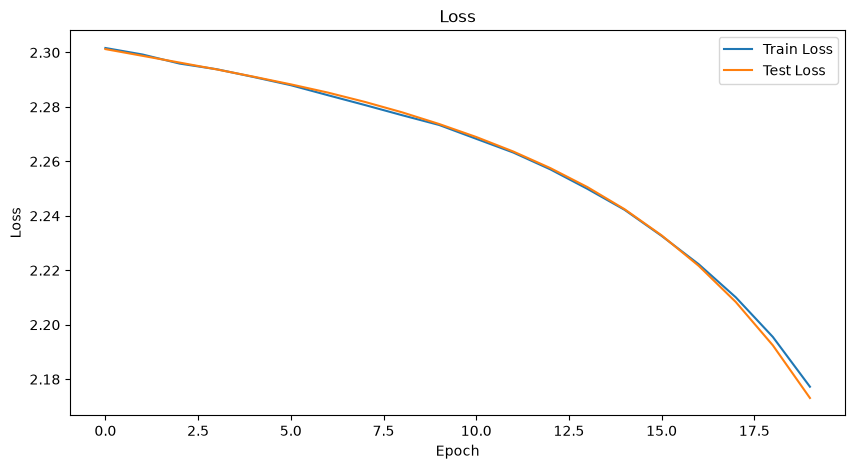

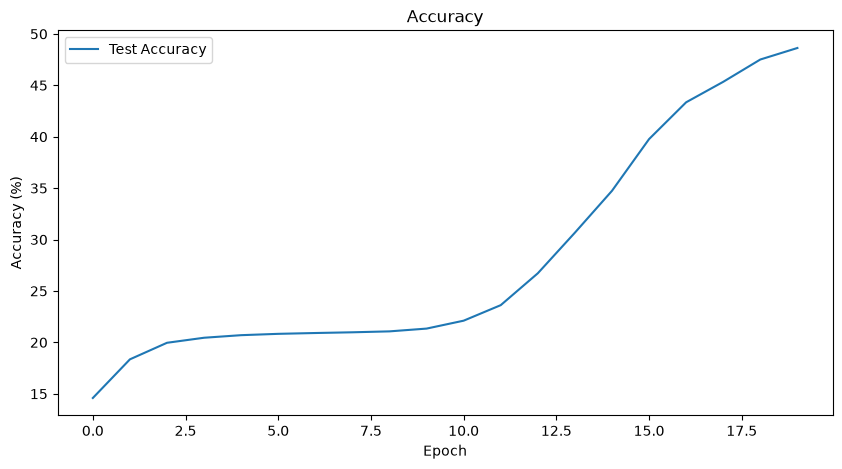

In [4]:
# 학습 및 평가 기록을 저장할 리스트
train_losses = []
test_losses = []
test_accuracies = []

num_epochs = 20
for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%')

# 손실 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Loss')
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 정확도 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [5]:
# 데이터 변환에 데이터 증강 기법 추가
transform_augmented = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# 데이터셋 및 로더 재정의
train_dataset_augmented = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_augmented)
train_subset_augmented = torch.utils.data.Subset(train_dataset_augmented, subset_indices)
train_loader_augmented = torch.utils.data.DataLoader(train_subset_augmented, batch_size=64, shuffle=True)

In [6]:
class ImprovedNet(nn.Module):
    def __init__(self):
        super(ImprovedNet, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(28*28, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.layer2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.relu1(self.bn1(self.layer1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer2(x))))
        x = self.relu3(self.bn3(self.layer3(x)))
        x = self.layer4(x)
        return x

# 모델, 손실 함수, 옵티마이저 재정의 (L2 정규화 적용)
model_improved = ImprovedNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_improved.parameters(), lr=0.01, weight_decay=0.001)

Epoch [1/20] - Train Loss: 2.2189, Test Loss: 2.1339, Accuracy: 42.22%
Epoch [2/20] - Train Loss: 1.9633, Test Loss: 1.7729, Accuracy: 69.28%
Epoch [3/20] - Train Loss: 1.7228, Test Loss: 1.5211, Accuracy: 73.80%
Epoch [4/20] - Train Loss: 1.5449, Test Loss: 1.3167, Accuracy: 75.82%
Epoch [5/20] - Train Loss: 1.3792, Test Loss: 1.1599, Accuracy: 77.54%
Epoch [6/20] - Train Loss: 1.2473, Test Loss: 1.0394, Accuracy: 79.49%
Epoch [7/20] - Train Loss: 1.1409, Test Loss: 0.9507, Accuracy: 81.47%
Epoch [8/20] - Train Loss: 1.0430, Test Loss: 0.8468, Accuracy: 82.90%
Epoch [9/20] - Train Loss: 0.9783, Test Loss: 0.7794, Accuracy: 84.15%
Epoch [10/20] - Train Loss: 0.9017, Test Loss: 0.7092, Accuracy: 85.32%
Epoch [11/20] - Train Loss: 0.8374, Test Loss: 0.6677, Accuracy: 86.35%
Epoch [12/20] - Train Loss: 0.7833, Test Loss: 0.6126, Accuracy: 86.66%
Epoch [13/20] - Train Loss: 0.7346, Test Loss: 0.5701, Accuracy: 87.22%
Epoch [14/20] - Train Loss: 0.7152, Test Loss: 0.5354, Accuracy: 87.72%
E

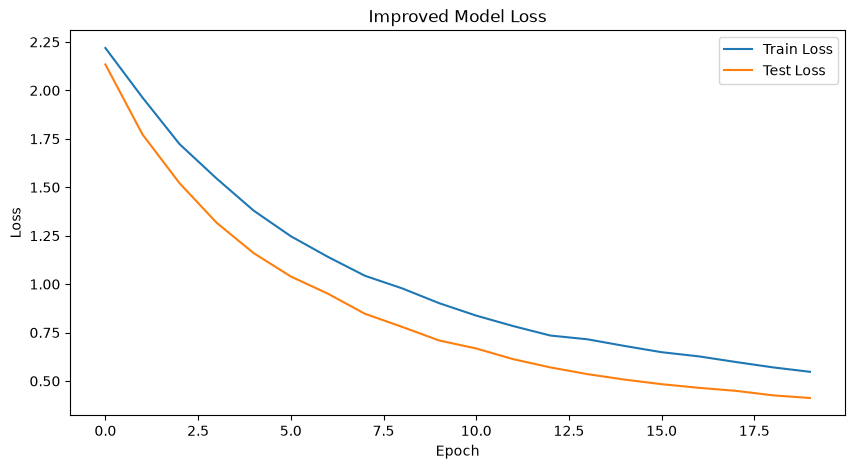

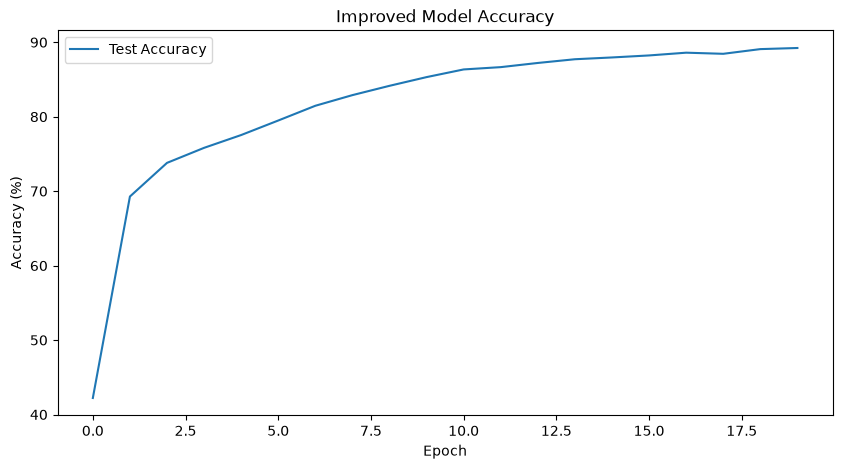

In [7]:
train_losses_improved = []
test_losses_improved = []
test_accuracies_improved = []

best_loss = float('inf')
patience = 3
trigger_times = 0

num_epochs = 20
for epoch in range(num_epochs):
    train_loss = train(model_improved, train_loader_augmented, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model_improved, test_loader, criterion)

    train_losses_improved.append(train_loss)
    test_losses_improved.append(test_loss)
    test_accuracies_improved.append(test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%')

    # 조기 종료 조건 확인
    if test_loss < best_loss:
        best_loss = test_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f'Early stopping counter: {trigger_times}/{patience}')
        if trigger_times >= patience:
            print('Early stopping!')
            break

# 손실 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Improved Model Loss')
plt.plot(train_losses_improved, label='Train Loss')
plt.plot(test_losses_improved, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 정확도 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Improved Model Accuracy')
plt.plot(test_accuracies_improved, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score

# 성별 구별을 위한 데이터 생성
np.random.seed(42)

# 1000명의 데이터를 생성: 나이, 키, 체중 특성
# 나이: 18~60, 키: 150~190 cm, 체중: 40~100 kg
X = np.random.rand(1000, 3).astype(np.float32)
X[:, 0] = X[:, 0] * 43 + 18  # 나이: 18~60
X[:, 1] = X[:, 1] * 40 + 150  # 키: 150~190
X[:, 2] = X[:, 2] * 60 + 40  # 체중: 40~100

# 성별 (0: 여자, 1: 남자) 라벨 생성
y = (X[:, 0] > 30).astype(np.float32)  # 30세 이상이면 남자, 아니면 여자

# 데이터셋 나누기 (훈련과 테스트)
train_size = int(0.8 * len(X))  # 80% 훈련 데이터
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# DataLoader 설정
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 모델 정의
class GenderNN(nn.Module):
    def __init__(self):
        super(GenderNN, self).__init__()
        self.fc1 = nn.Linear(3, 64)  # 3개의 입력 특성 (나이, 키, 체중)
        self.dropout = nn.Dropout(0.5)  # 드롭아웃 적용
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)  # 이진 분류 (여자: 0, 남자: 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 첫 번째 은닉층
        x = self.dropout(x)  # 드롭아웃 적용
        x = torch.relu(self.fc2(x))  # 두 번째 은닉층
        x = torch.sigmoid(self.fc3(x))  # 출력층
        return x

# 모델 인스턴스
model = GenderNN()

# 손실 함수와 옵티마이저 설정
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

# 훈련 함수
def train(model, train_loader, criterion, optimizer, epochs=10):
    model.train()  # 훈련 모드로 설정
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()  # 기울기 초기화

            # 순전파
            outputs = model(inputs)

            # 손실 계산
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()  # 역전파
            optimizer.step()  # 가중치 업데이트

            running_loss += loss.item()

        # 에포크마다 손실 출력
        print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader)}')

# 훈련 시작
train(model, train_loader, criterion, optimizer, epochs=10)

# 테스트 함수
def test(model, test_loader):
    model.eval()  # 평가 모드로 설정
    all_preds = []
    all_labels = []
    with torch.no_grad():  # 기울기 계산을 하지 않음
        for inputs, labels in test_loader:
            outputs = model(inputs)
            preds = (outputs.squeeze() > 0.5).float() # 0.5를 기준으로 이진 예측
            all_preds.append(preds)
            all_labels.append(labels)

    # 결과를 텐서에서 numpy로 변환
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # 정확도 계산
    accuracy = accuracy_score(all_labels, all_preds)
    print(f'Accuracy on test data: {accuracy * 100:.2f}%')

# 테스트 시작
test(model, test_loader)

Epoch 1/10, Loss: 10.907417590801533
Epoch 2/10, Loss: 16.554544889009914
Epoch 3/10, Loss: 4.931765281237089
Epoch 4/10, Loss: 1.860786497592926
Epoch 5/10, Loss: 1.17355837730261
Epoch 6/10, Loss: 0.8308070049836085
Epoch 7/10, Loss: 0.7821104664068955
Epoch 8/10, Loss: 0.7445900577765244
Epoch 9/10, Loss: 0.708778074154487
Epoch 10/10, Loss: 0.6252179375061622
Accuracy on test data: 94.00%
